# Analyse the discharge prediction (forecast mode)

We first load results from "*test_results.pickle*", outputed by the training procedure. Then, we can visualize the results, e.g., rainfall and discharge (Sim vs. Obs)

Note, this notebook works with the "forecast mode", where the output metrics are forecast_NSE and forecast_PNSE.

In [6]:
# Import necessary packages
import pickle
import os
import sys
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.ticker as ticker

sys.path.append("..")
from hy2dl.evaluation.metrics import forecast_NSE, forecast_PNSE

# colorblind friendly palette
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

In [7]:
# Load the test_results from a pickle file
file_path = r"D:\Research\Projects\Hy2DL\results\bs_256_uniqueBlocksTrue\test_results.pickle"

# Path to save the excel file with rainfall and discharge values
test_result_save_path = r"D:\Research\Projects\Hy2DL\results\bs_256_uniqueBlocksTrue\test_results"

# create_folder(folder_path=test_result_save_path)
os.makedirs(test_result_save_path, exist_ok=True)

# Load the test results
with open(file_path, "rb") as f:
    test_results = pickle.load(f)

## 1. Show metric value in a figure

Show forecast_NSE and PNSE for each lead time

D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:91: RuntimeWarning: Mean of empty slice
  denominator = np.nansum((y_obs - np.nanmean(y_obs, axis=0)) ** 2, axis=0)
D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:92: RuntimeWarning: invalid value encountered in scalar divide
  nse_per_leadtime.append(1 - numerator / denominator)
D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:150: RuntimeWarning: invalid value encountered in scalar divide
  nse_per_leadtime.append(1 - numerator / denominator)


The avearge of 'median forecast_NSE' across all lead times:  0.786


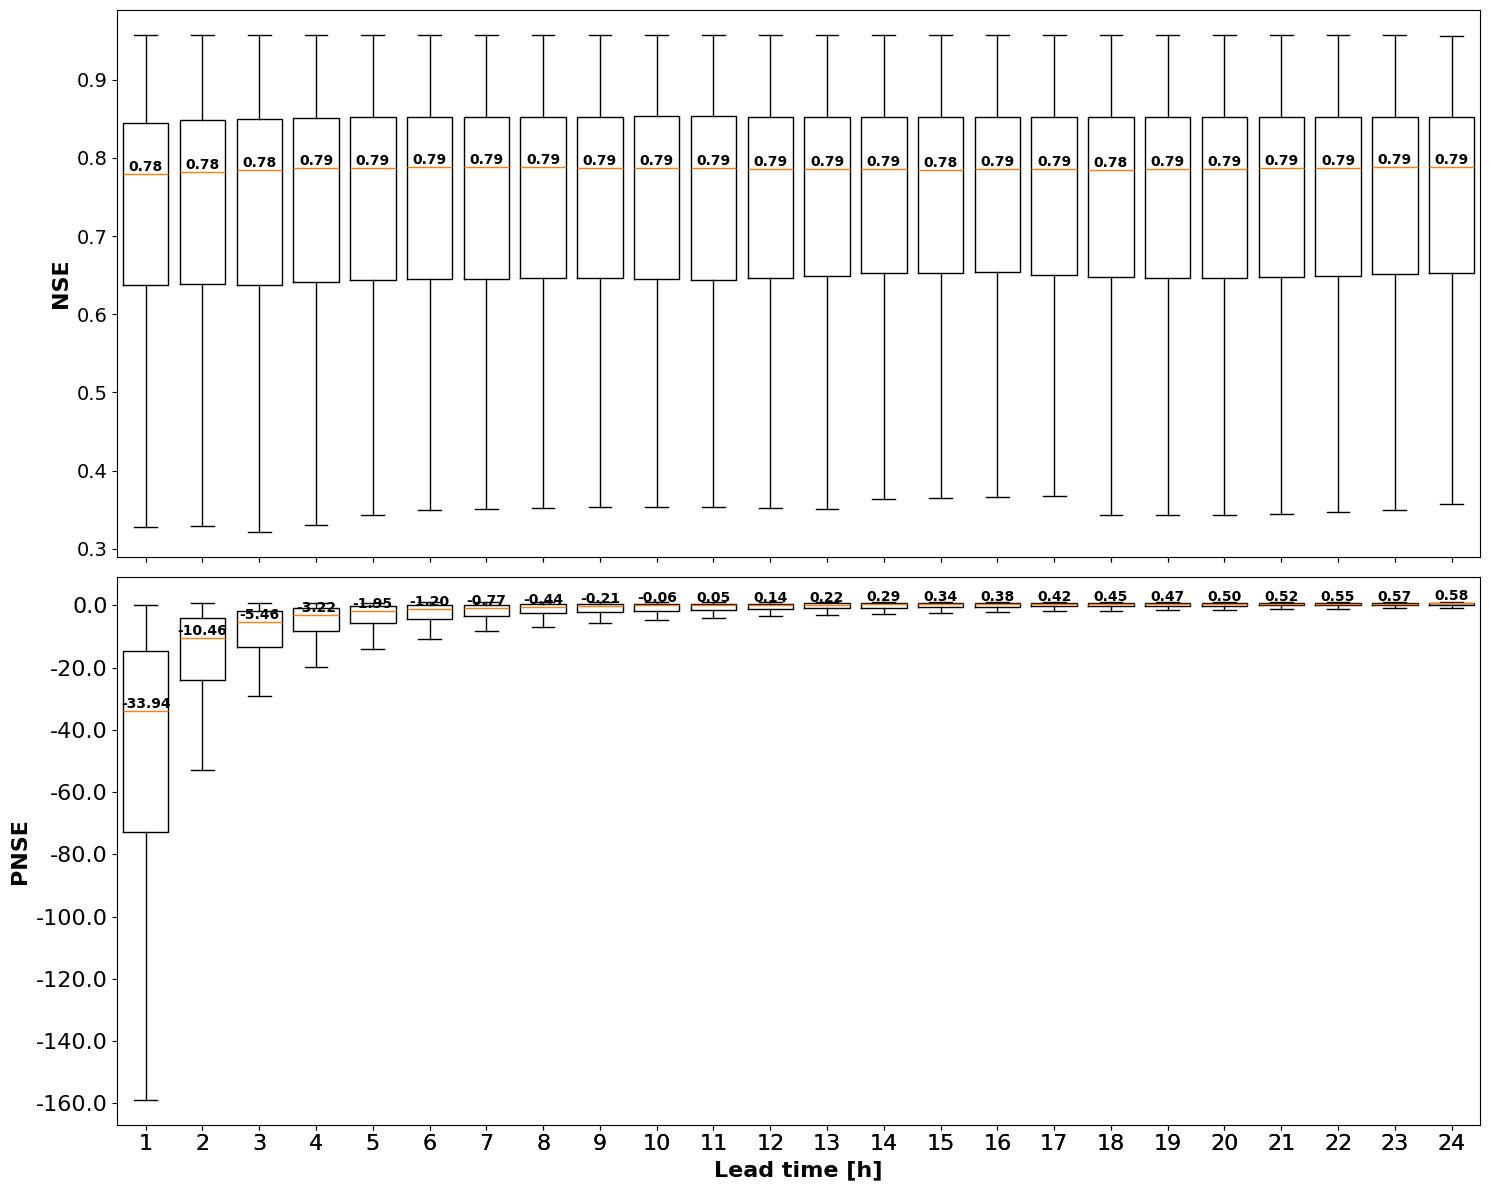

In [15]:
df_NSE = forecast_NSE(results=test_results)
df_PNSE = forecast_PNSE(results=test_results)

# Calculate the median forecast_NSE across all basins for each lead time
# Then, output the average value across all lead times
print("The avearge of 'median forecast_NSE' across all lead times: ", f"{df_NSE.median().mean():.3f}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharex=True)  # Share x-axis

# First subplot: NSE
axes[0].boxplot(
    df_NSE.dropna().values,
    widths=0.8,
    positions=np.arange(len(df_NSE.columns)) + 1,
    showfliers=False,
)

medians = df_NSE.median(axis=0).values
for i, median in enumerate(medians):
    axes[0].text(
        i + 1,
        median,
        f"{median:.2f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

axes[0].set_ylabel("NSE", fontsize=16, fontweight="bold")
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
axes[0].tick_params(axis="both", labelsize=14)

# Second subplot: Boxplot
axes[1].boxplot(
    df_PNSE.dropna().values,
    widths=0.8,
    positions=np.arange(len(df_PNSE.columns)) + 1,
    showfliers=False,
)

# Add median values as text
medians = df_PNSE.median(axis=0).values
for i, median in enumerate(medians):
    axes[1].text(
        i + 1,
        median,
        f"{median:.2f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=10,
        fontweight="bold",
        color="black",
    )

axes[1].set_xlabel("Lead time [h]", fontsize=16, fontweight="bold")
axes[1].set_ylabel("PNSE", fontsize=16, fontweight="bold")
axes[1].tick_params(axis="both", labelsize=16)
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

# Adjust layout
plt.tight_layout()
plt.show()

## 2. Save NSE for each basin in a .CSV file

In [3]:
df_NSE = forecast_NSE(results=test_results)
df_PNSE = forecast_PNSE(results=test_results)

# Save the NSE for each basin in a csv file
df_NSE.to_csv(os.path.join(test_result_save_path, "NSE_testing.csv"), index=True, header=True)
df_PNSE.to_csv(os.path.join(test_result_save_path, "PNSE_testing.csv"), index=True, header=True)

D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:91: RuntimeWarning: Mean of empty slice
  denominator = np.nansum((y_obs - np.nanmean(y_obs, axis=0)) ** 2, axis=0)
D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:92: RuntimeWarning: invalid value encountered in scalar divide
  nse_per_leadtime.append(1 - numerator / denominator)
D:\Research\Projects\Hy2DL\src\hy2dl\evaluation\metrics.py:150: RuntimeWarning: invalid value encountered in scalar divide
  nse_per_leadtime.append(1 - numerator / denominator)


## 3. Draw R-Q (Sim and obs) graph (For one basin)

In [5]:
# Select one basin for analysis
basin_to_analyze = "DE213740"  # the biggest basin
# basin_to_analyze = "DE211270" # the smallest basin

# View the first few rows of the DataFrame for one basin
# print(f"The first rows of the basin {basin_to_analyze}: \n {test_results[basin_to_analyze].head()}")

# # read csv file ro obatin rainfall data
file_path = f"D:\Research\Projects\Hy2DL\data\CAMELS_DE\hourly\CAMELS_DE_1h_hydromet_timeseries_{basin_to_analyze}.csv"
df = pd.read_csv(file_path)

# convert date form
df['time'] = pd.to_datetime(df['time'])

### 3.1 Show one random window with a Q peak

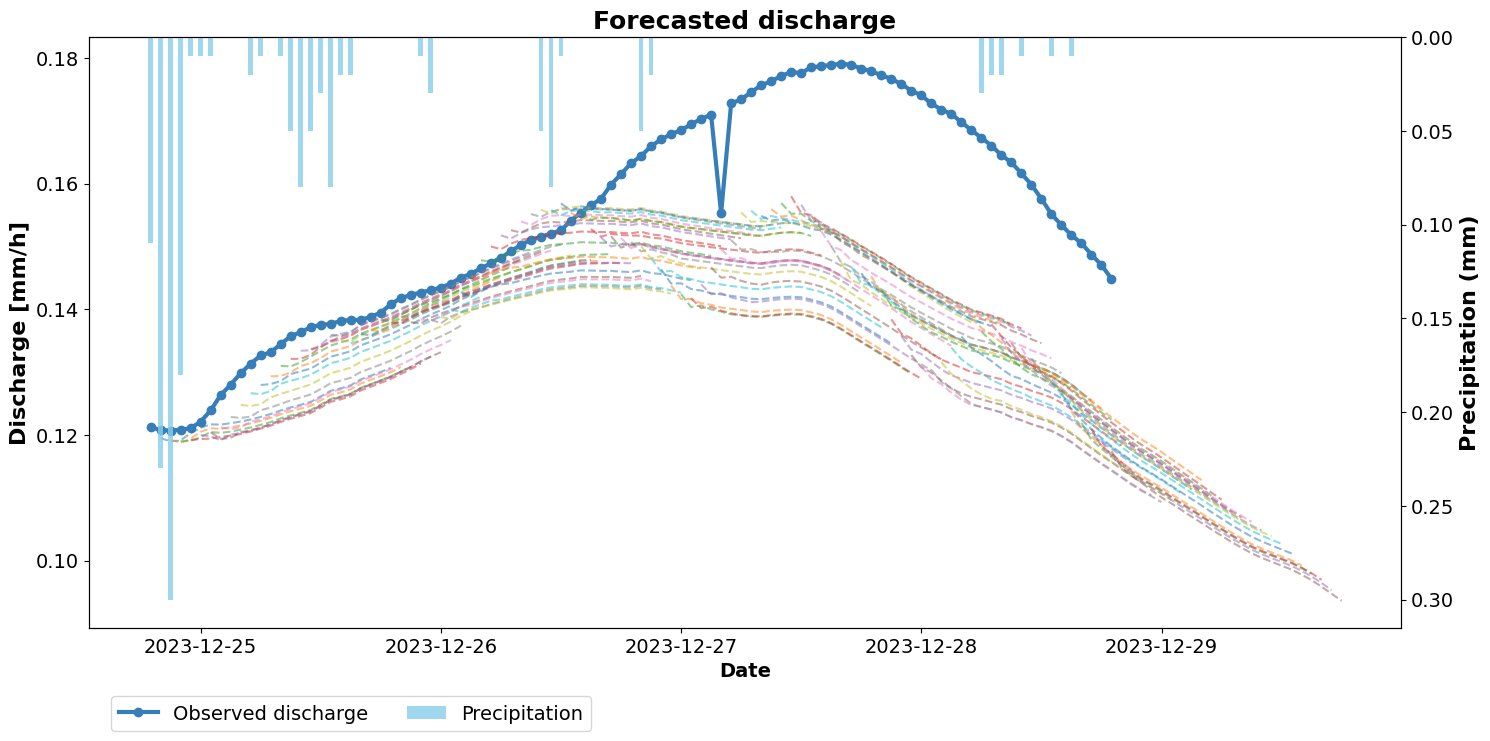

In [7]:
# Establish period of interest as 48 hours before and after a random peak
date = random.sample(list(test_results[basin_to_analyze].Observed.nlargest(200).index), 1)[0]  # select one of the max 200 peaks
window_size = 48
start_date = date - pd.Timedelta(hours=window_size)
end_date = date + pd.Timedelta(hours=window_size)
period_of_interest = [start_date, end_date]

# Filter the results
df_period_of_interest = test_results[basin_to_analyze].loc[period_of_interest[0] : period_of_interest[1], :]

# Extract precipitation data for the same period
df_prec = df.loc[(df['time'] >= period_of_interest[0]) & (df['time'] <= period_of_interest[1])]
df_prec = df_prec.set_index('time')['precipitation_sum_mean']

# Create figure
fig, ax1 = plt.subplots(figsize=(15, 7.5))

# Observe series
ax1.plot(
    df_period_of_interest["Observed"],
    label="Observed discharge",
    color=color_palette["observed"],
    linewidth=3,
    marker="o",
)

# Simulated forecasted series
for i in range(df_period_of_interest.shape[0] - 1):
    time_slide = pd.date_range(
        start=df_period_of_interest.index[i + 1], periods=df_period_of_interest.shape[1] - 1, freq="h"
    )

    forecast = df_period_of_interest.iloc[i, 1:].values
    ax1.plot(time_slide, forecast, alpha=0.5, linestyle="--")

# Precipitation
ax2 = ax1.twinx()
ax2.bar(df_prec.index, df_prec.squeeze().values, color="skyblue", width=0.02, label="Precipitation", alpha=0.8)

# Format plot
ax1.set_xlabel("Date", fontsize=14, fontweight="bold")
ax1.tick_params(axis="x", labelsize=14)
ax1.set_ylabel("Discharge [mm/h]", fontsize=16, fontweight="bold")
ax1.tick_params(axis="y", labelsize=14)
ax1.set_title("Forecasted discharge", fontsize=18, fontweight="bold")

ax2.set_ylabel("Precipitation (mm)", fontsize=16, fontweight="bold")
ax2.tick_params(axis="both", which="major", labelsize=14)
ax2.invert_yaxis()

# Create legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper center", bbox_to_anchor=(0.2, -0.1), ncol=5, fontsize=14)

plt.tight_layout()
# plt.savefig(config.path_save_folder / "Forecasted_discharge.jpg")
plt.show()

### 3.2 To do: Draw discharge graph (Sim vs. Obs)

We can select to show (1) the whole test time period, or (2) a custom time period

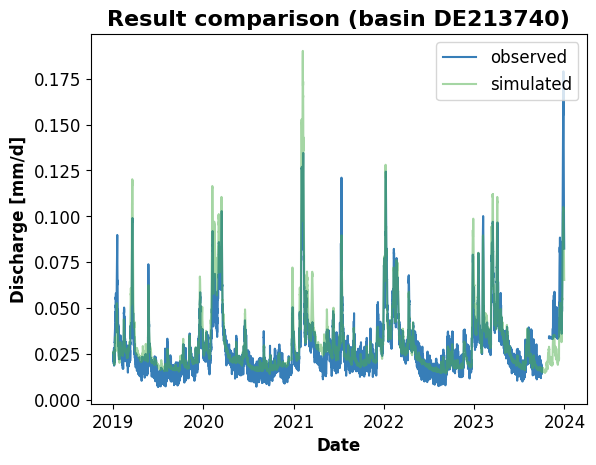

In [6]:
# colorblind friendly palette
color_palette = {"observed": "#377eb8", "simulated": "#4daf4a"}

# # (1) Output time window of test dataset period
plt.plot(test_results[basin_to_analyze]["y_obs"], label="observed", color=color_palette["observed"])
plt.plot(test_results[basin_to_analyze]["y_sim"], label="simulated", alpha=0.5, color=color_palette["simulated"])

# # (2) Output custom time window
# start_date = "2021-04-01 01:00:00"
# end_date = "2021-04-07 01:00:00"
# plt.plot(test_results[basin_to_analyze]["y_obs"][start_date:end_date], label="observed", color=color_palette["observed"])
# plt.plot(test_results[basin_to_analyze]["y_sim"][start_date:end_date], label="simulated", alpha=0.5, color=color_palette["simulated"])

# Format plot
plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Discharge [mm/d]", fontsize=12, fontweight="bold")
plt.title(f"Result comparison (basin {basin_to_analyze})", fontsize=16, fontweight="bold")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.legend(loc="upper right", fontsize=12)
# plt.savefig(os.path.join(test_result_save_path, f"Result comparison (basin {basin_to_analyze}).png"), bbox_inches="tight", pad_inches=0)

### 3.3 To do: Draw hydrograph: rainfall and discharge (sim vs. obs)

We can select to show (1) the whole test time period, or (2) a custom time period

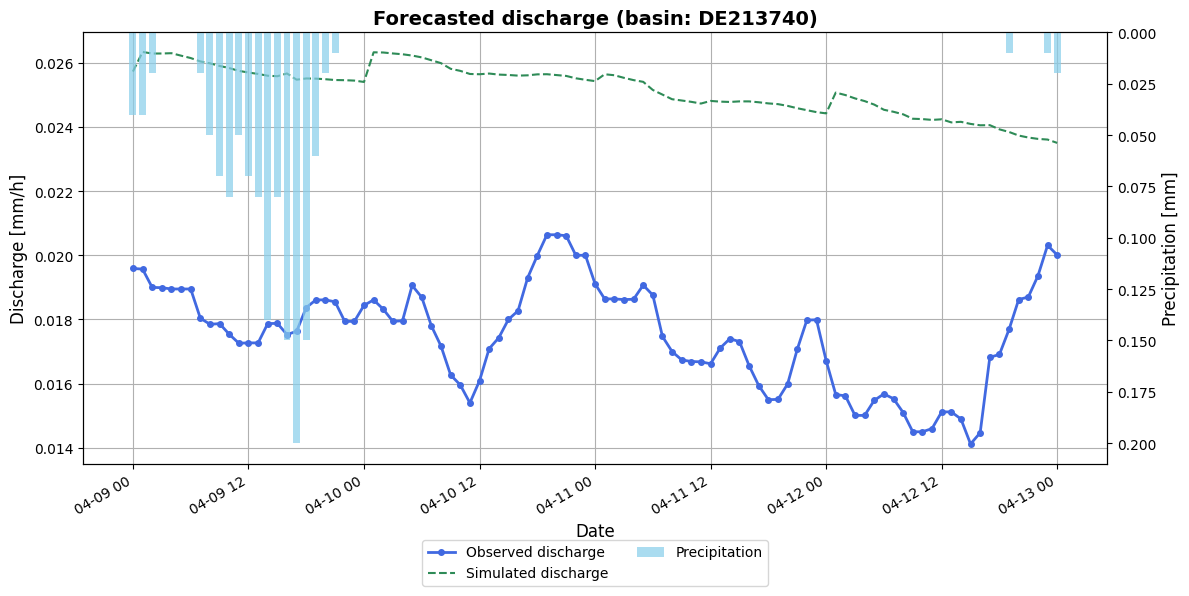

In [7]:
# (1) Output whole time window of test dataset period
# start_date = test_results[basin_to_analyze]["y_obs"].index[0]
# end_date = test_results[basin_to_analyze]["y_obs"].index[-1]
# start_date = pd.to_datetime(start_time)
# end_date = pd.to_datetime(end_time)

# (2) Output custom time window
start_date = "2019-04-09 00:00:00"
end_date = "2019-04-13 00:00:00"

rainfall_df_plot = rainfall_df[(rainfall_df[time_label[0]] >= start_date) & (rainfall_df[time_label[0]] <= end_date)]

# 创建图形和主坐标轴
fig, ax1 = plt.subplots(figsize=(12, 6))

# 设置主坐标轴（径流）
ax1.plot(rainfall_df_plot[time_label[0]], test_results[basin_to_analyze]["y_obs"][start_date:end_date], label='Observed discharge', color='royalblue', linewidth=2, marker='o', markersize=4)
ax1.plot(rainfall_df_plot[time_label[0]], test_results[basin_to_analyze]["y_sim"][start_date:end_date], label='Simulated discharge', color='seagreen', linestyle='--')
ax1.set_ylabel("Discharge [mm/h]", fontsize=12)
ax1.set_xlabel("Date", fontsize=12)
ax1.tick_params(axis='y')
ax1.legend(loc='lower left')
ax1.grid(True)

# 创建次坐标轴（降雨）
ax2 = ax1.twinx()
ax2.bar(rainfall_df_plot[time_label[0]], rainfall_df_plot[target_variables[0]], width=0.03, label='Precipitation', color='skyblue', alpha=0.7)
ax2.set_ylabel("Precipitation [mm]", fontsize=12)
ax2.tick_params(axis='y')
ax2.invert_yaxis()  # 降雨显示在图的上方

# 设置标题
plt.title(f"Forecasted discharge (basin: {basin_to_analyze})", fontsize=14, weight='bold')

# 合并图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)

# 自动格式化日期
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

### 3.4 To do: Save rainfall and discharge value (Sim vs. Obs) in a .csv file

In [8]:
# Extract DataFrame
df = test_results[basin_to_analyze].copy()

if isinstance(df.index, pd.DatetimeIndex):
    df.reset_index(inplace=True)
    df.rename(columns={"index": time_label[0]}, inplace=True)

merged_df = pd.merge(df, rainfall_df[[time_label[0], target_variables[0]]],
                     left_on=time_label[0], right_on=time_label[0], how="left")

# # 去掉重复的时间列（若存在）This is Not tested
# if time_label[0] != "date":
#     merged_df.drop(columns=[time_label[0]], inplace=True)

# Save observed and predicted results in Excel files
file_name = f"pred_basin_{basin_to_analyze}.csv"

# Save the predicted flow for each timestep in a csv file
merged_df.to_csv(os.path.join(test_result_save_path,file_name), index=False)

print(f"Data for basin {basin_to_analyze} has been saved to {test_result_save_path}")

Data for basin DE213740 has been saved to D:\Research\Projects\Hy2DL\results\Edu_14_day_seed_110\test_results
